# Summary of mapping data

In this notebook we summarize and filter the barcode-promoter mapping and compile everything into a table.

In [1]:
from glob import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import regseq2

regseq2.viz.matplotlib_style()

We import the file names for all promoters (which are in the file names). The. first file is removed, as it contains all the sequenced variants that could not be matched to a promoter.

In [2]:
files = np.sort(glob("../../data/barcode_map/*.txt"))[1:]

Now we import each file and filter out any pairs of barcodes and promoter variants that have less than two reads, to make sure we remove any sequencing errors that made it past quality control.

In [3]:
df_list = []

for file in files:
    df = pd.read_csv(file, names=['promoter', 'barcode', 'count', 'name'])
    df = df[df['count'] > 2]
    df_list.append(df)

Barcodes need to me unique to a promoter variant. So here we filter out any barcodes that map to more than one promoter variant and only keep unique barcodes.

In [ ]:
df_map = pd.concat(df_list)
df_final = df_map[~df_map['barcode'].duplicated(keep=False)].copy()
df_final.to_csv("../../data/mapping/mapped_barcodes_filtered.csv")

In [40]:
df_final

,promoter,barcode,count,name
24,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAACTAACTCAACAACACCA,59,TSS_1414_storz_regulondb
25,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAATCGTAGCCCGTTCCTAC,80,TSS_1414_storz_regulondb
26,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAGCATTTCAACGGAGGACA,13,TSS_1414_storz_regulondb
27,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAGCCTACCGATCTGCAGCC,91,TSS_1414_storz_regulondb
32,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AGGTCACATGGGCGATAGAC,40,TSS_1414_storz_regulondb
...,...,...,...,...
85515,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,CGTGTAAACGTCAAGTTAGT,10,znuCp
85516,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,CTTTCATAAAGACGCTCCGG,105,znuCp
85517,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,GTACTATAACAATCGCGTTG,206,znuCp
85519,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,GTATTAGACTGGTACAAATA,85,znuCp


## DicA binding site in dicC promoter

The promoter for dicC contains a binding site for DicA, which we can find by looking at the mutation rate across all sequenced promoter variants for the dicC promoter.


In [5]:
mut_mat = np.zeros([4, 160])
let_dict = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

for _, row in df_final[df_final['name'] == 'dicCp'].iterrows():
    for i, l in enumerate(row['promoter']):
        mut_mat[let_dict[l], i] += row['count']

In [6]:
mut_mat /= np.sum(mut_mat, axis=0)

In [7]:
mut_rate  = 1-np.max(mut_mat, axis=0)

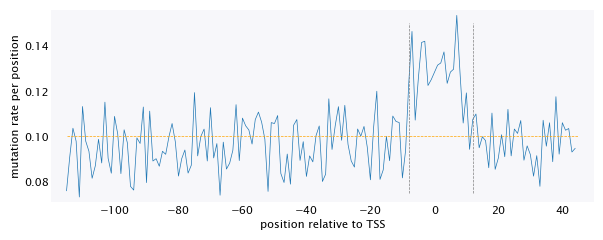

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.5))
ax.plot(np.arange(-115, 45), mut_rate)
ax.plot([-115, 45], [0.1, 0.1], ls='--', color='orange')
ax.vlines([-8, 12], ymin=0.075, ymax=0.15, ls='--', color='gray')

ax.set_xlabel('position relative to TSS')
ax.set_ylabel('mutation rate per position')

fig.savefig('pdf_files/dicC_mutation_rate.pdf')

In [46]:
sequences = df_final[df_final['name'] == 'dicCp']['promoter'].unique()
len(sequences)

2524

In [61]:
min_rows = 1

df_filtered = df_final.groupby("promoter").filter(
    lambda g: len(g) > min_rows
)
df_filtered['promoter'].nunique()

175257

(array([   3.,    8.,   27., 1494.,  882.,   56.,   32.,    6.,    4.,
          12.]),
 array([11. , 12.3, 13.6, 14.9, 16.2, 17.5, 18.8, 20.1, 21.4, 22.7, 24. ]),
 <BarContainer object of 10 artists>)

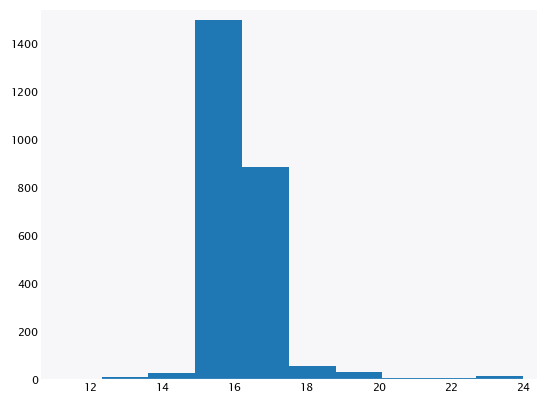

In [ ]:
wt = "ACCTGTAATTCCAAGCGTCTACTAGTGAGGTTTTTCCGACGATACCTGATGCGTTCGCCGATAGTTAAATTTTTTGTTTCCATAGTTAGCTAATGCTAAATCGTATTGACTATGTTTTTGTTAACATCTATCTTGTTAGTTATGACTAACAATAAAGGTGTTTTAAATGCTTAAAACTGACGCTCTGGGCCCCCGGGATTCAGTGATTGAACGTGTAAAATCCGAGAACCGAATACGTGCCTGAGACAAC"[26:186]
n_mutations = [160 - np.sum([x == y for x, y in zip(list(seq), list(wt))]) for seq in sequences]
plt.hist(n_mutations)

In [47]:
df_old = pd.read_csv("/Volumes/rp_lab_ext/1000_genes_ecoli/data/barcodes/20220514_mapping/100_per_gene/dicCp_barcodes.txt", names=['promoter', 'barcode', 'counts', 'name'])
df_old = df_old[df_old['counts'] > 2]

(array([   3.,    9.,   29., 1675., 2871.,  160.,   36.,    7.,    4.,
          16.]),
 array([11. , 12.3, 13.6, 14.9, 16.2, 17.5, 18.8, 20.1, 21.4, 22.7, 24. ]),
 <BarContainer object of 10 artists>)

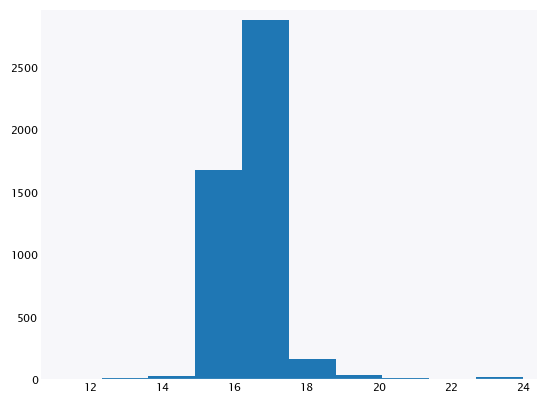

In [49]:
n_mutations = [160 - np.sum([x == y for x, y in zip(list(seq), list(wt))]) for seq in df_old['promoter'].unique()]
plt.hist(n_mutations)

In [ ]:
min_rows = 3

df_filtered = df_old.groupby("promoter").filter(
    lambda g: len(g) > min_rows
)
df_filtered['promoter'].nunique()

1258

In [52]:
df_filtered['promoter'].nunique()

1516

## Barcode distribution

In [62]:
df_unique = df_filtered.groupby('name')['promoter'].nunique().sort_values(ascending=True)

In [63]:
df_unique

name
dicCp     1168
tnaCp     1307
crpp1     1343
lpp       1365
yqaEp     1365
          ... 
ompFp     2928
ybeDp     2942
cpxRp2    2961
mglBp     3001
mtnp      3040
Name: promoter, Length: 112, dtype: int64

In [64]:
tss_names = {
    "TSS_1414_storz_regulondb": 'yahM',
    'TSS_18061_regulondb': 'yjjJ',
    'TSS_4654_wanner_regulondb': 'ymfJ',
    'TSS_4655_regulondb': 'ymfJ_2',
    'TSS_6311_regulondb': 'dicA',
}


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_30772/915281306.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=4.5);


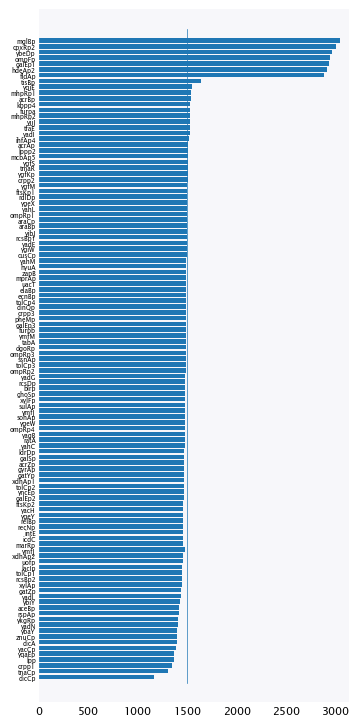

In [ ]:
fig, ax = plt.subplots(figsize=(4, 9))

labels = [tss_names[x] if x in tss_names.keys() else x for x in df_unique.index]
labels = [x.split('_')[0] for x in labels]

ax.barh(labels, df_unique.values)

ax.set_yticklabels(labels, fontsize=4.5)
ax.plot([1500, 1500], [-1, 112])
ax.set_lim('')

In [20]:
df_unique.values

array([8726, 7289, 6693, 6138, 6085, 5962, 5192, 5150, 4999, 4992, 4980,
       4932, 4804, 4789, 4588, 4552, 4543, 4517, 4425, 4419, 4224, 4203,
       4202, 4090, 4080, 3922, 3845, 3841, 3735, 3587, 3583, 3581, 3573,
       3523, 3515, 3490, 3478, 3421, 3416, 3413, 3350, 3347, 3297, 3246,
       3227, 3218, 3185, 3161, 3158, 3137, 3136, 3123, 3102, 3067, 3061,
       3039, 3039, 3037, 3034, 3027, 3008, 2961, 2958, 2945, 2917, 2873,
       2860, 2857, 2842, 2820, 2789, 2773, 2772, 2756, 2755, 2746, 2715,
       2714, 2694, 2692, 2690, 2670, 2644, 2622, 2613, 2594, 2593, 2551,
       2551, 2524, 2511, 2498, 2491, 2464, 2462, 2449, 2407, 2400, 2327,
       2300, 2287, 2284, 2267, 2245, 2232, 2145, 2081, 1975, 1775, 1711,
       1694, 1663])